In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.naive_bayes import GaussianNB

In [201]:
shopping_trends = pd.read_csv("shopping_trends.csv")

In [202]:
shopping_trends.keys()

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [203]:
shopping_trends.shape

(3900, 19)

In [204]:
shopping_trends.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Venmo,Standard,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Debit Card,Free Shipping,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Debit Card,Free Shipping,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Venmo,Express,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,PayPal,2-Day Shipping,Yes,Yes,4,Cash,Quarterly


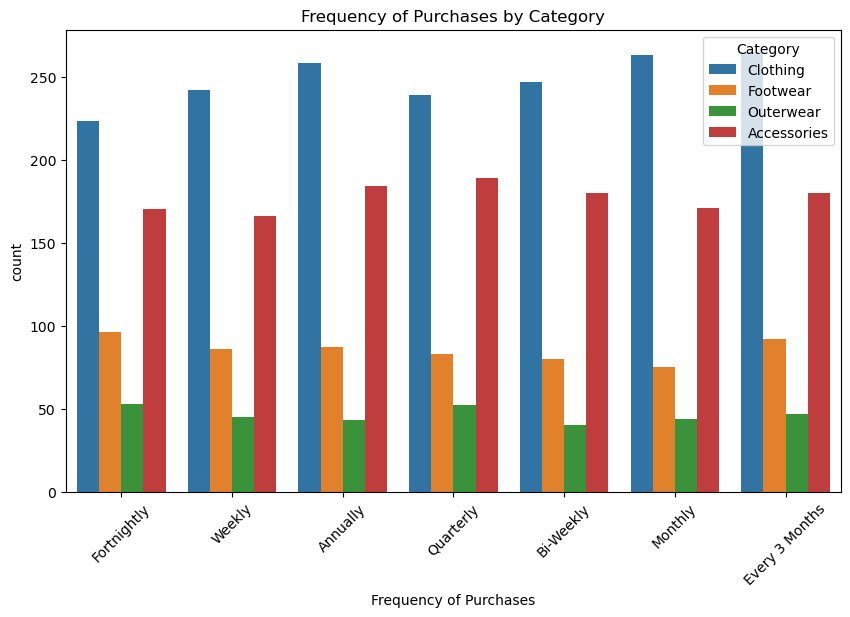

In [205]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Frequency of Purchases', hue='Category', data=shopping_trends)
plt.title('Frequency of Purchases by Category')
plt.xticks(rotation=45)
plt.show()

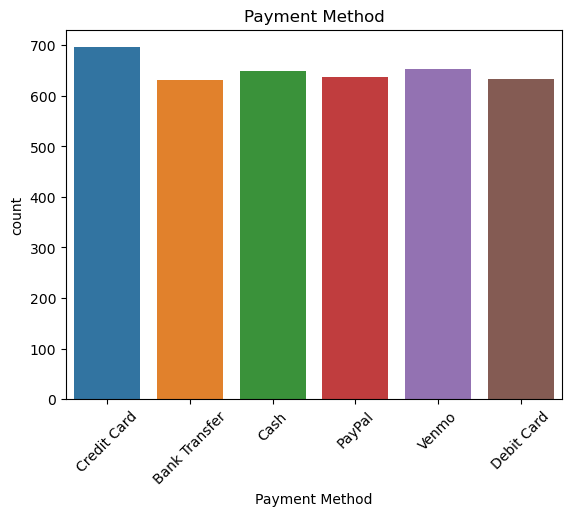

In [206]:
sns.countplot(x='Payment Method', data=shopping_trends)
plt.xticks(rotation=45)
plt.title("Payment Method")
plt.show()

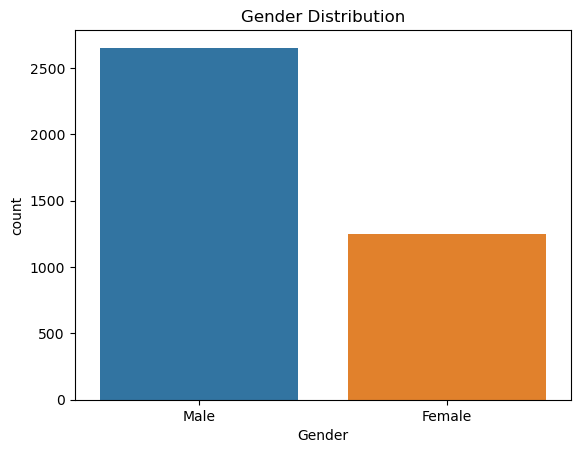

In [207]:
sns.countplot(x='Gender', data=shopping_trends)
plt.title("Gender Distribution")
plt.show()

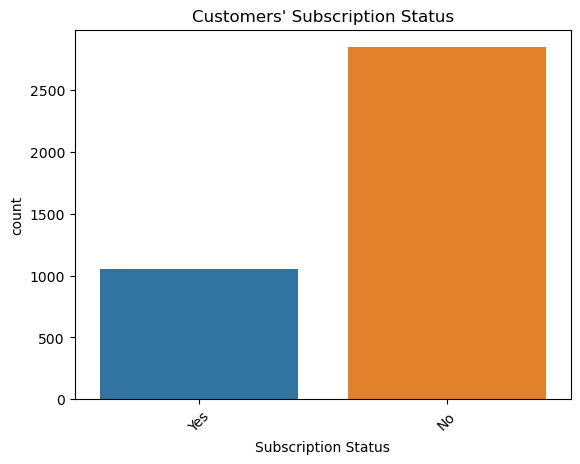

In [208]:
sns.countplot(x='Subscription Status', data=shopping_trends)
plt.xticks(rotation=45)
plt.title("Customers' Subscription Status")
plt.show()

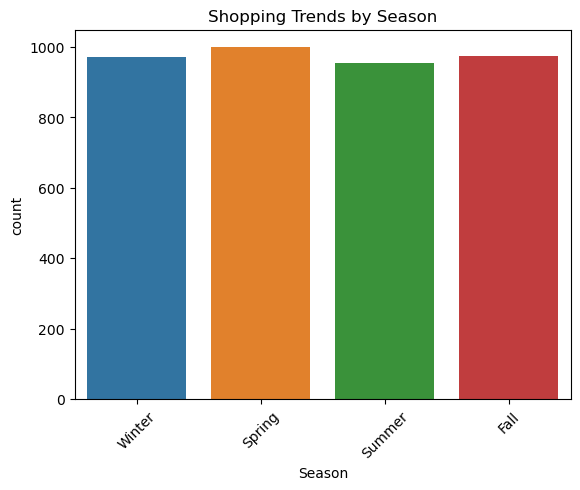

In [209]:
sns.countplot(x='Season', data=shopping_trends)
plt.xticks(rotation=45)
plt.title("Shopping Trends by Season")
plt.show()

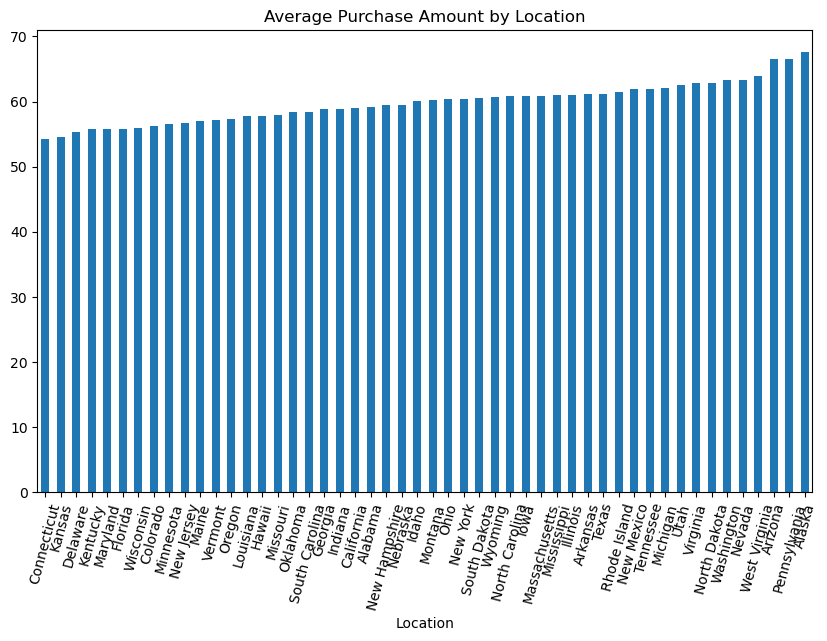

In [210]:
plt.figure(figsize=(10,6))
shopping_trends.groupby('Location')['Purchase Amount (USD)'].mean().sort_values() \
    .plot(kind='bar')
plt.title('Average Purchase Amount by Location')
plt.xticks(rotation= 75)
plt.show()

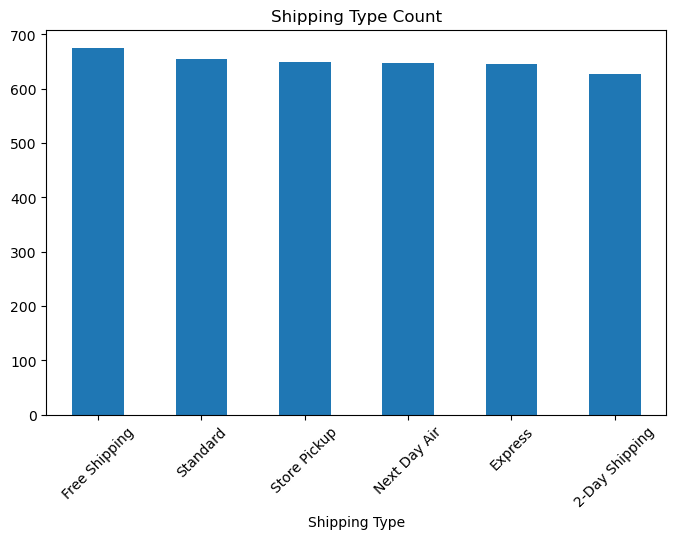

In [211]:
plt.figure(figsize=(8,5))
shopping_trends['Shipping Type'].value_counts().plot(kind='bar')
plt.title('Shipping Type Count')
plt.xticks(rotation=45)
plt.show()

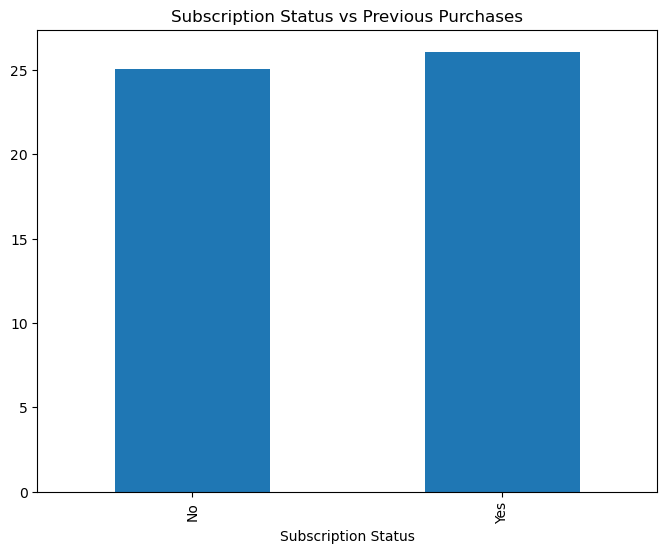

In [212]:
plt.figure(figsize=(8,6))
shopping_trends.groupby('Subscription Status')['Previous Purchases'].mean().plot.bar()
plt.title('Subscription Status vs Previous Purchases')
plt.show()

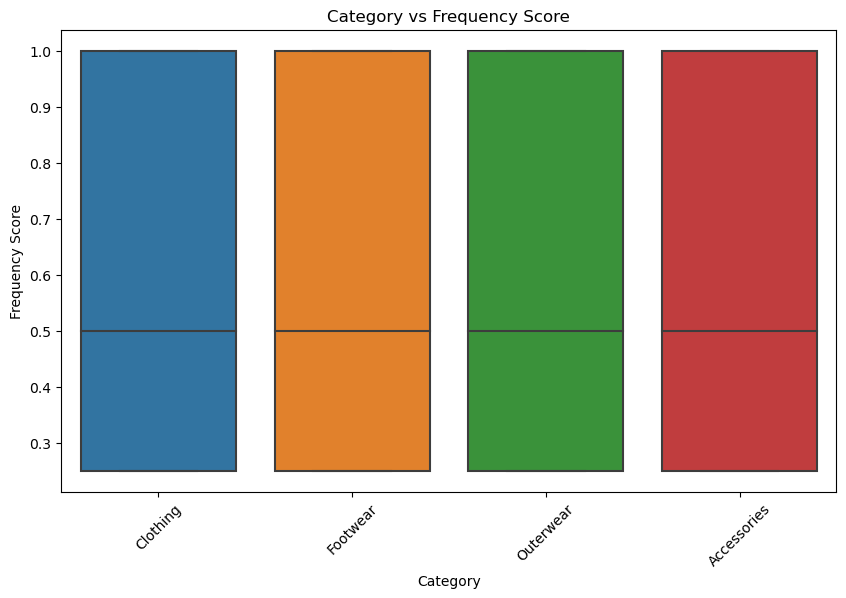

In [213]:
freq_map = {'Daily': 7, 'Weekly': 1, 'Fortnightly': 0.5, 'Monthly': 0.25}
shopping_trends['Frequency Score'] = shopping_trends['Frequency of Purchases'].map(freq_map)
plt.figure(figsize=(10,6))
sns.boxplot(data=shopping_trends, x='Category', y='Frequency Score')
plt.xticks(rotation=45)
plt.title('Category vs Frequency Score')
plt.show()

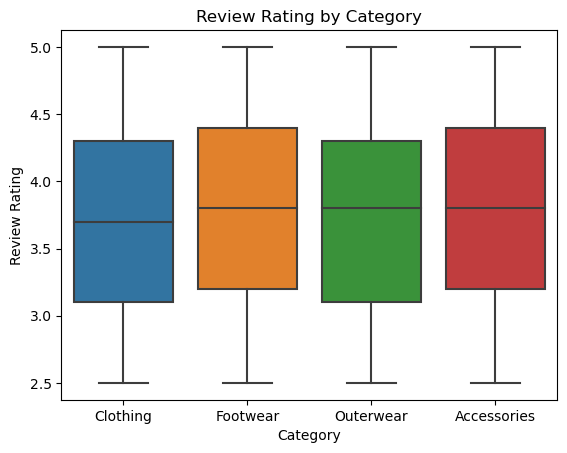

In [214]:
sns.boxplot(x='Category', y='Review Rating', data=shopping_trends)
plt.title('Review Rating by Category')
plt.show()

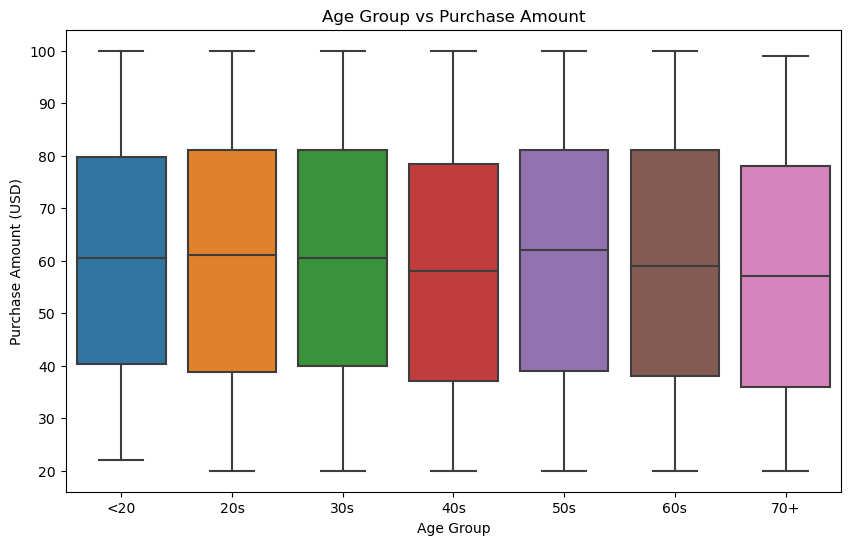

In [215]:
shopping_trends['Age Group'] = pd.cut(
    shopping_trends['Age'],
    bins=[0,19,29,39,49,59,69,100],
    labels=['<20','20s','30s','40s','50s','60s','70+'])
plt.figure(figsize=(10,6))
sns.boxplot(data=shopping_trends, x='Age Group', y='Purchase Amount (USD)')
plt.title('Age Group vs Purchase Amount')
plt.show()

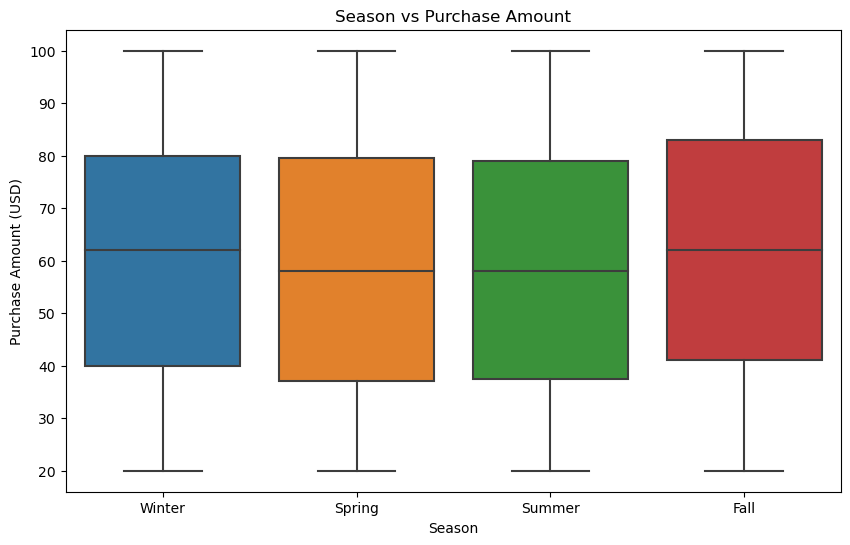

In [216]:
plt.figure(figsize=(10,6))
sns.boxplot(data=shopping_trends, x='Season', y='Purchase Amount (USD)')
plt.title('Season vs Purchase Amount')
plt.show()

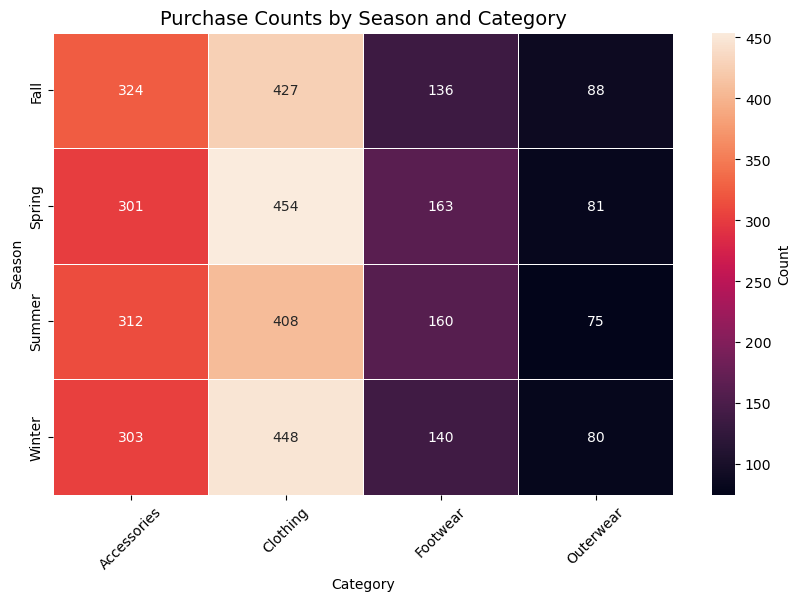

In [217]:
cross = pd.crosstab(shopping_trends['Season'], shopping_trends['Category'])
plt.figure(figsize=(10, 6))
sns.heatmap(cross, annot=True, fmt='d', cmap='rocket', linewidths=0.5, cbar_kws={'label': 'Count'})
plt.title('Purchase Counts by Season and Category', fontsize=14)
plt.xticks(rotation=45)
plt.show()

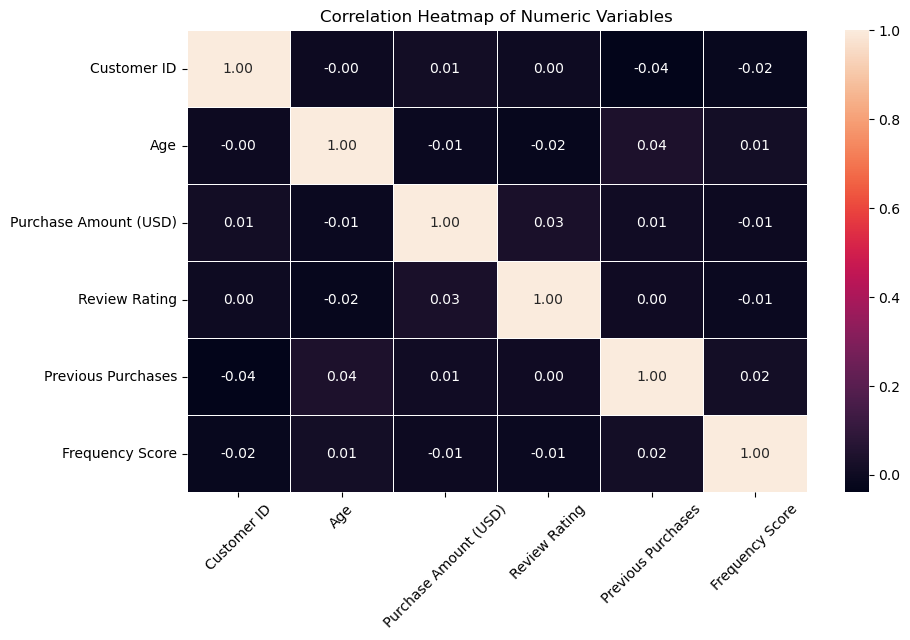

In [218]:
numeric_df = shopping_trends.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='rocket', fmt=".2f", linewidths=0.5)
plt.xticks(rotation=45)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

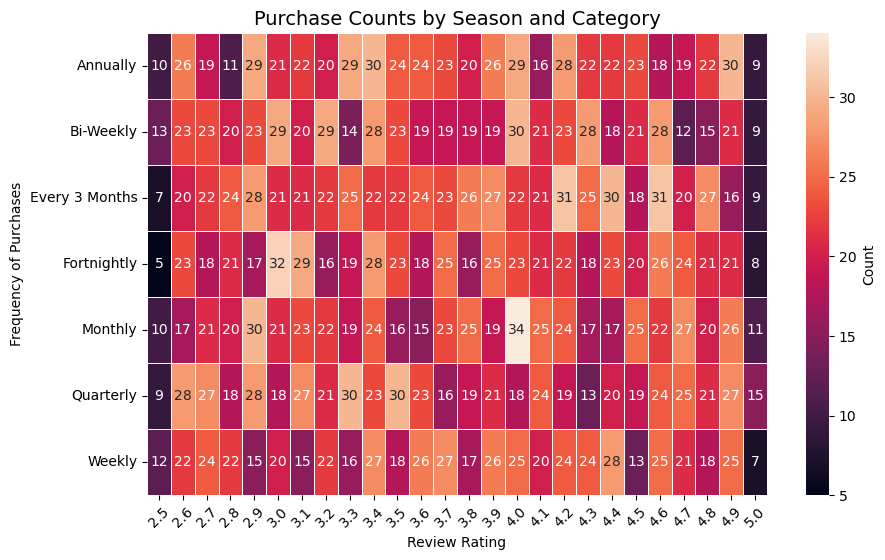

In [219]:

cross = pd.crosstab(shopping_trends['Frequency of Purchases'], shopping_trends['Review Rating'])
plt.figure(figsize=(10, 6))
sns.heatmap(cross, annot=True, fmt='d', cmap='rocket', linewidths=0.5, cbar_kws={'label': 'Count'})
plt.title('Purchase Counts by Season and Category', fontsize=14)
plt.xticks(rotation=45)
plt.show()

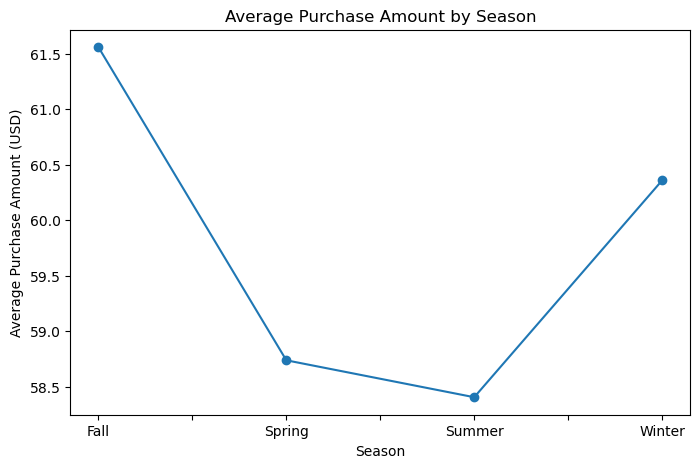

In [220]:
shopping_trends.groupby('Season')['Purchase Amount (USD)'].mean().plot.line( marker='o', figsize=(8, 5))
plt.title("Average Purchase Amount by Season")
plt.ylabel("Average Purchase Amount (USD)")
plt.show()

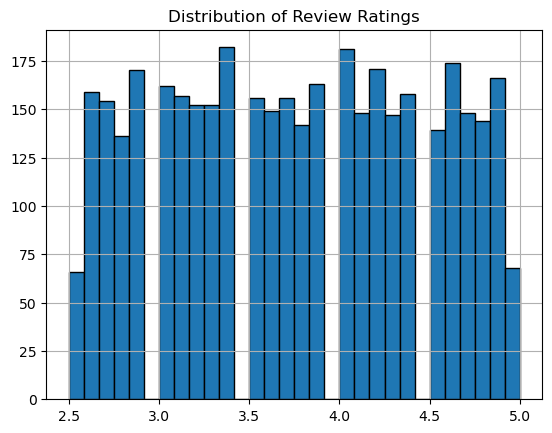

In [221]:
shopping_trends['Review Rating'].hist(bins=30, edgecolor='black')
plt.title('Distribution of Review Ratings')
plt.show()

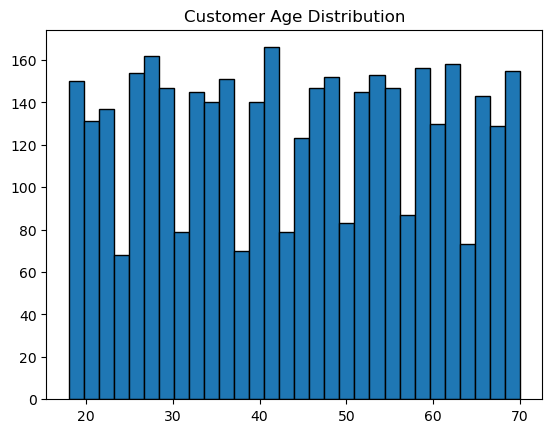

In [222]:
plt.hist(shopping_trends['Age'], bins=30, edgecolor='black')
plt.title('Customer Age Distribution')
plt.show()

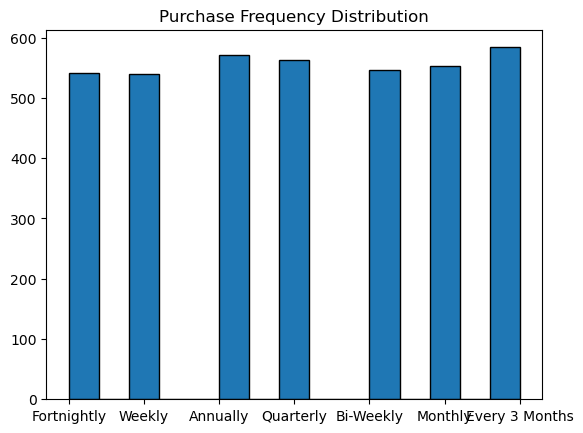

In [223]:
plt.hist(shopping_trends['Frequency of Purchases'], bins=15, edgecolor='black')
plt.title('Purchase Frequency Distribution')
plt.show()

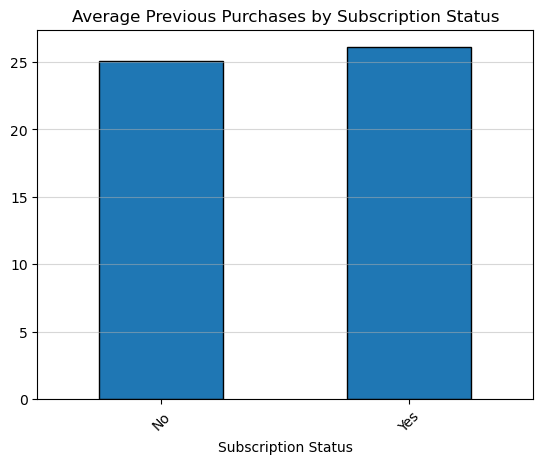

In [224]:
category_means = shopping_trends.groupby('Subscription Status')['Previous Purchases'].mean().sort_values()
bars = category_means.plot.bar(edgecolor='black')
plt.title("Average Previous Purchases by Subscription Status")
plt.grid(axis='y', alpha=0.5)
plt.xticks(rotation=45)
plt.show()


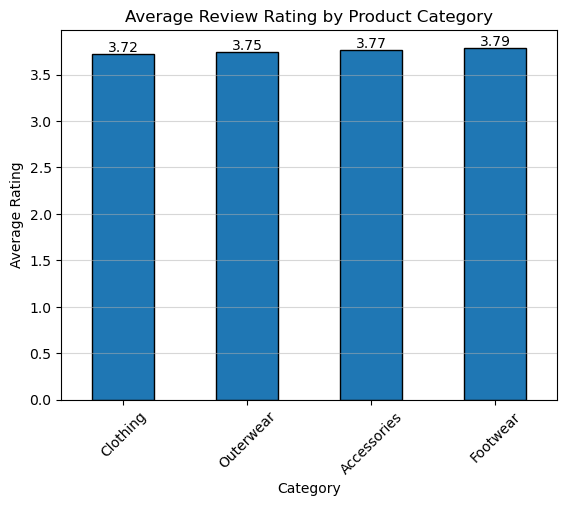

In [225]:
category_means = shopping_trends.groupby('Category')['Review Rating'].mean().sort_values()
bars = category_means.plot.bar(edgecolor='black')
plt.title("Average Review Rating by Product Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.grid(axis='y', alpha=0.5)
for bar in bars.patches:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.2f}",
        ha='center',
    )
plt.xticks(rotation=45)
plt.show()


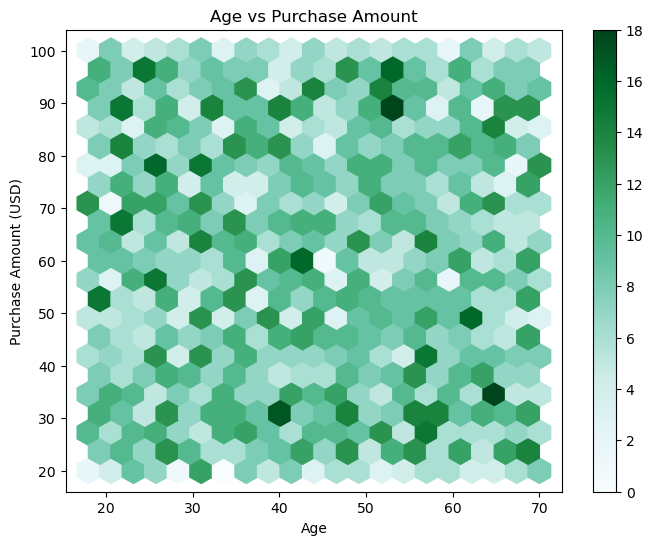

In [226]:
shopping_trends.plot.hexbin(x='Age', y='Purchase Amount (USD)', gridsize=20, figsize=(8,6))
plt.title("Age vs Purchase Amount")
plt.show()

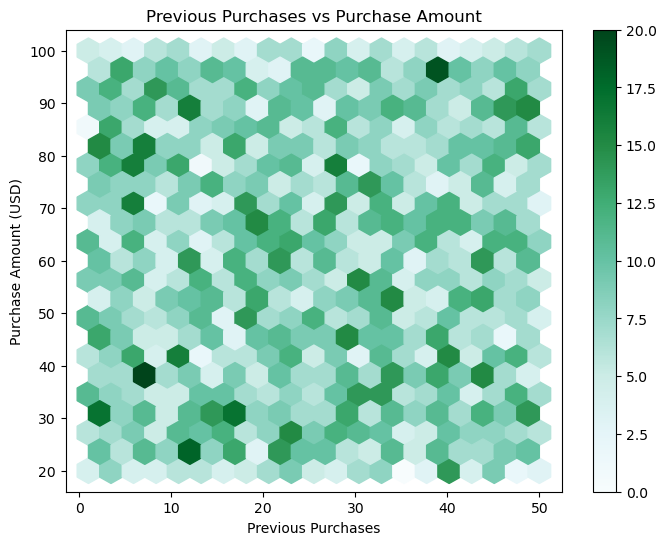

In [227]:
shopping_trends.plot.hexbin(x='Previous Purchases', y='Purchase Amount (USD)', gridsize=20, figsize=(8,6))
plt.title("Previous Purchases vs Purchase Amount")
plt.show()

<Axes: xlabel='Previous Purchases', ylabel='Purchase Amount (USD)'>

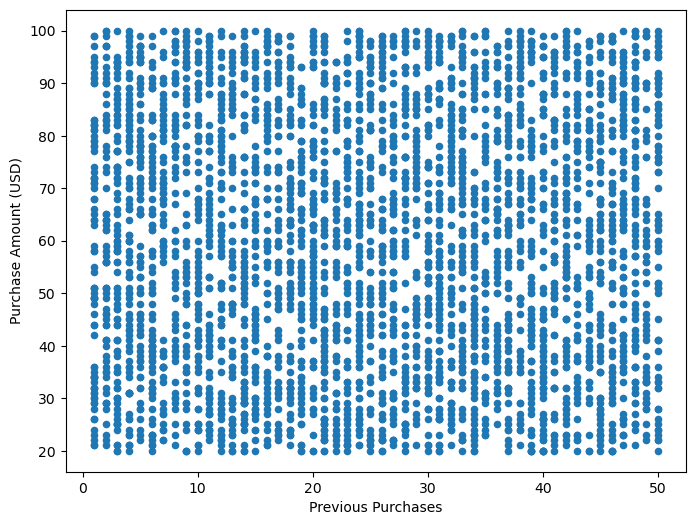

In [228]:
shopping_trends.plot.scatter(x='Previous Purchases', y='Purchase Amount (USD)', figsize=(8,6))

<Axes: xlabel='Review Rating', ylabel='Purchase Amount (USD)'>

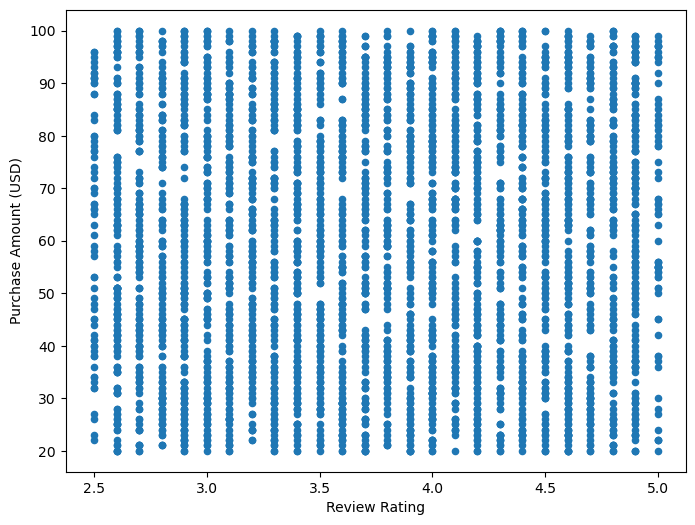

In [229]:
shopping_trends.plot.scatter(x='Review Rating', y='Purchase Amount (USD)', figsize=(8,6))

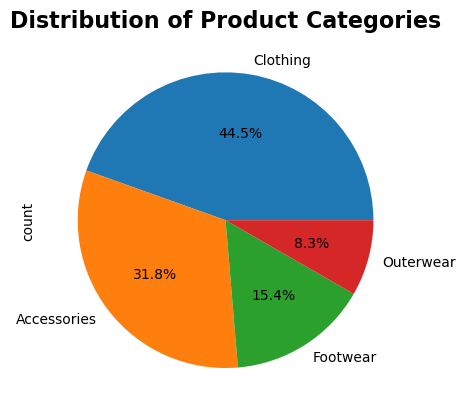

In [231]:
shopping_trends['Category'].value_counts().plot.pie( autopct='%1.1f%%')
plt.title('Distribution of Product Categories', fontsize=16, weight='bold')
plt.show()

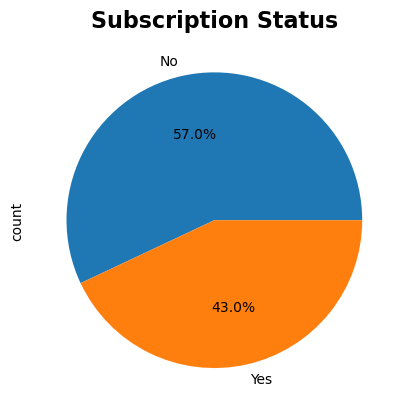

In [232]:
shopping_trends['Discount Applied'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Subscription Status', fontsize=16, weight='bold')
plt.show()

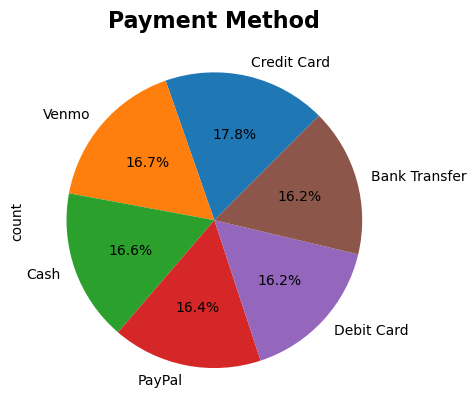

In [233]:
shopping_trends['Payment Method'].value_counts().plot.pie( startangle=45, autopct='%1.1f%%')
plt.title('Payment Method', fontsize=16, weight='bold')
plt.show()

In [199]:
x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=0)

NameError: name 'train_test_split' is not defined

In [160]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test  = sc.fit_transform(x_test)

NameError: name 'StandardScaler' is not defined

In [ ]:
x = SNA.iloc[:,[2, 3]].values    # predictor attribute
y = SNA.iloc[:,4].values 

In [240]:
shopping_trends.info

<bound method DataFrame.info of       Customer ID  Age  Gender Item Purchased     Category  \
0               1   55    Male         Blouse     Clothing   
1               2   19    Male        Sweater     Clothing   
2               3   50    Male          Jeans     Clothing   
3               4   21    Male        Sandals     Footwear   
4               5   45    Male         Blouse     Clothing   
...           ...  ...     ...            ...          ...   
3895         3896   40  Female         Hoodie     Clothing   
3896         3897   52  Female       Backpack  Accessories   
3897         3898   46  Female           Belt  Accessories   
3898         3899   44  Female          Shoes     Footwear   
3899         3900   52  Female        Handbag  Accessories   

      Purchase Amount (USD)       Location Size      Color  Season  ...  \
0                        53       Kentucky    L       Gray  Winter  ...   
1                        64          Maine    L     Maroon  Winter  ...  

In [241]:
shopping_trends.isnull().sum()

Customer ID                    0
Age                            0
Gender                         0
Item Purchased                 0
Category                       0
Purchase Amount (USD)          0
Location                       0
Size                           0
Color                          0
Season                         0
Review Rating                  0
Subscription Status            0
Payment Method                 0
Shipping Type                  0
Discount Applied               0
Promo Code Used                0
Previous Purchases             0
Preferred Payment Method       0
Frequency of Purchases         0
Frequency Score             2266
Age Group                      0
dtype: int64

In [235]:
shopping_trends.dtypes

Customer ID                    int64
Age                            int64
Gender                        object
Item Purchased                object
Category                      object
Purchase Amount (USD)          int64
Location                      object
Size                          object
Color                         object
Season                        object
Review Rating                float64
Subscription Status           object
Payment Method                object
Shipping Type                 object
Discount Applied              object
Promo Code Used               object
Previous Purchases             int64
Preferred Payment Method      object
Frequency of Purchases        object
Frequency Score              float64
Age Group                   category
dtype: object

In [236]:
shopping_trends.shape

(3900, 21)

In [237]:
shopping_trends.keys()

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases', 'Frequency Score', 'Age Group'],
      dtype='object')

In [238]:
shopping_trends.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Frequency Score
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,1634.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538,0.580324
std,1125.977353,15.207589,23.685392,0.716223,14.447125,0.311811
min,1.000000,18.000000,20.000000,2.500000,1.000000,0.250000
25%,975.750000,31.000000,39.000000,3.100000,13.000000,0.250000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000,0.500000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000,1.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000,1.000000


In [239]:
shopping_trends.ndim

2

In [242]:
shopping_trends[].value_counts()

SyntaxError: invalid syntax (3638074479.py, line 1)

In [ ]:
classifier = GaussianNB()